In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix
)

# Required algorithms from Section 4.5
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

In [27]:
# Load dataset
data = pd.read_csv('../dataset/heart.csv')[:1300]

# PREVENTION 1: Deduplication to eliminate train-test leakage
print(f"Dataset shape before deduplication: {data.shape}")
data = data.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after deduplication: {data.shape}")

# Separate features (X) and label (y)
X = data.drop('target', axis=1)
y = data['target']

# PREVENTION 2: Stratified Split to preserve target distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Dataset shape before deduplication: (1300, 14)
Dataset shape after deduplication: (302, 14)


In [28]:
# PREVENTION 3: Regularized Hyperparameters to limit model complexity
raw_models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_split=10, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42),
    "Support Vector Machine": SVC(C=1.0, kernel='rbf', random_state=42),
    "K-Nearest Neighbour": KNeighborsClassifier(n_neighbors=7)
}

results = []
trained_pipelines = {}
test_predictions = {}

# Stratified 5-Fold Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in raw_models.items():
    # PREVENTION 4: Pipeline scaling to prevent feature leakage across CV folds
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    # Stratified K-Fold Cross Validation
    cv_scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=['accuracy', 'f1'], return_train_score=True
    )
    
    # Train pipeline on full training dataset
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    trained_pipelines[name] = pipeline
    test_predictions[name] = y_pred
    
    # Compile performance metrics for Table 4.2
    results.append({
        "Model": name,
        "CV Train Acc (%)": round(cv_scores['train_accuracy'].mean() * 100, 2),
        "CV Val Acc (%)": round(cv_scores['test_accuracy'].mean() * 100, 2),
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred) * 100, 2),
        "F1-Score (%)": round(f1_score(y_test, y_pred) * 100, 2)
    })

# Render Table 4.2
table_4_2 = pd.DataFrame(results)
print("Table 4.6: Performance Comparison of Machine Learning Models")
display(table_4_2)

Table 4.6: Performance Comparison of Machine Learning Models


,Model,CV Train Acc (%),CV Val Acc (%),Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,85.99,83.79,80.33,80.00,84.85,82.35
1,Decision Tree,88.17,79.68,72.13,75.00,72.73,73.85
2,Random Forest,95.54,84.63,77.05,78.79,78.79,78.79
3,Support Vector Machine,93.05,85.04,77.05,77.14,81.82,79.41
4,K-Nearest Neighbour,86.83,82.96,78.69,77.78,84.85,81.16


Selected Best Model: Logistic Regression



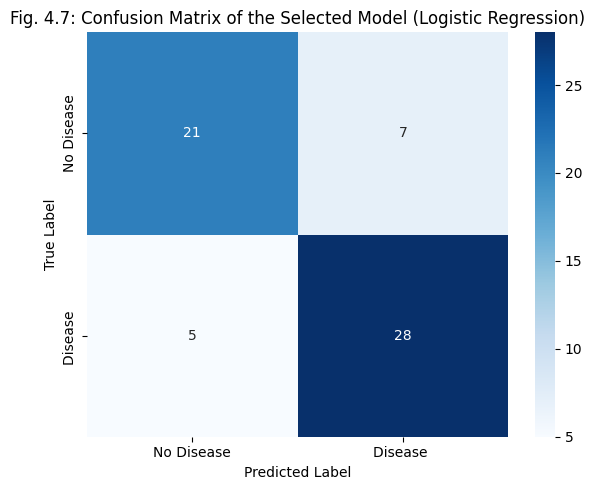

In [29]:
# Best model selected based on F1-Score & Validation Accuracy (Generalization ability)
best_model_name = table_4_2.sort_values(
    by=["F1-Score (%)", "CV Val Acc (%)"], ascending=False
).iloc[0]["Model"]

print(f"Selected Best Model: {best_model_name}\n")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, test_predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease', 'Disease '],
    yticklabels=['No Disease', 'Disease ']
)
plt.title(f"Fig. 4.7: Confusion Matrix of the Selected Model ({best_model_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [30]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Select winning pipeline
best_pipeline = trained_pipelines[best_model_name]

# Define input tensor schema
initial_type = [("float_input", FloatTensorType([None, X.shape[1]]))]

# Convert to ONNX format
onnx_model = convert_sklearn(best_pipeline, initial_types=initial_type)

file_name = f"../models/heart_disease_{best_model_name.lower().replace(' ', '_')}_pipeline.onnx"
with open(file_name, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Successfully exported pipeline to {file_name}")

Successfully exported pipeline to ../models/heart_disease_logistic_regression_pipeline.onnx
